In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
# Carregar os dados da aba 1
df1 = pd.read_excel(r"C:\Users\embras\Desktop\Anderson\Python\fm2s\[FM2S] Lista_Exercícios_ 3 e 4.xlsx", sheet_name="1.Teste_Medicamento")

In [8]:
# Configurar o estilo dos gráficos
sns.set_theme(style="whitegrid")

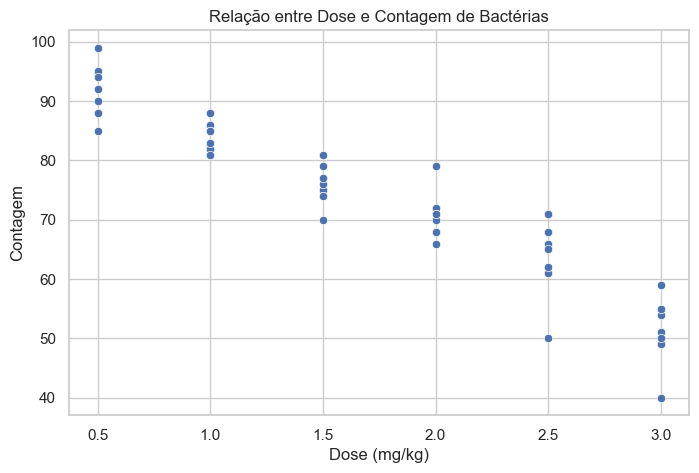

In [9]:
# a) A dosagem influencia na contagem final?
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df1, x="Dose (mg/kg)", y="Contagem")
plt.title("Relação entre Dose e Contagem de Bactérias")
plt.show()

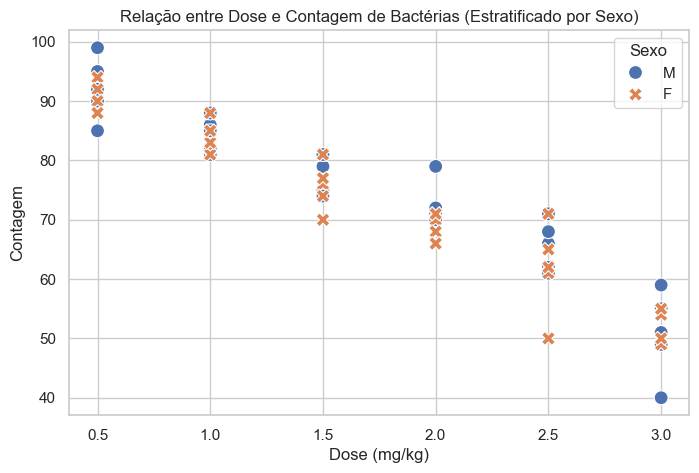

In [10]:
# b) O sexo tem correlação com a contagem? Estratifique a sua análise.
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df1, x="Dose (mg/kg)", y="Contagem", hue="Sexo", style="Sexo", s=100)
plt.title("Relação entre Dose e Contagem de Bactérias (Estratificado por Sexo)")
plt.show()

In [11]:
# c) Análise de eficácia e melhor dosagem
media_por_dose = df1.groupby("Dose (mg/kg)")["Contagem"].mean().reset_index()
print("Média de contagem de bactérias por dose:")
print(media_por_dose)

Média de contagem de bactérias por dose:
   Dose (mg/kg)  Contagem
0           0.5      91.3
1           1.0      84.1
2           1.5      76.2
3           2.0      70.8
4           2.5      63.7
5           3.0      51.7


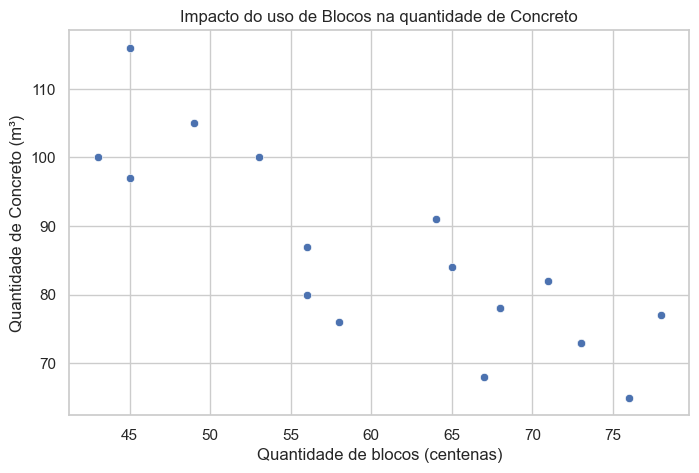

In [16]:
# Carregar os dados da aba 2
df2 = pd.read_excel(r"C:\Users\embras\Desktop\Anderson\Python\fm2s\[FM2S] Lista_Exercícios_ 3 e 4.xlsx", sheet_name="2.Construtora")

# a) Aumentar o número de blocos reduz a quantidade de cimento?
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df2, x="Quantidade de blocos (centenas)", y="Quantidade de Concreto (m³)")
plt.title("Impacto do uso de Blocos na quantidade de Concreto")
plt.show()

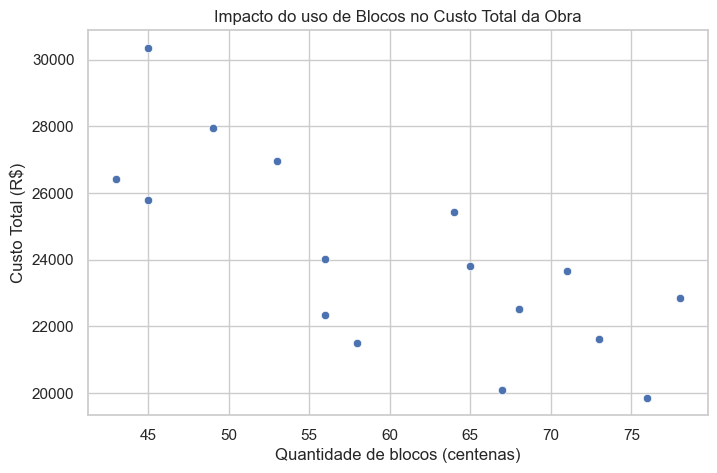

In [17]:
# b) Aumentar o número de blocos reduz o custo total da obra?
# Custo = (Concreto * 240) + (Blocos_Centenas * 56)
df2["Custo Total (R$)"] = (df2["Quantidade de Concreto (m³)"] * 240) + (df2["Quantidade de blocos (centenas)"] * 56)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df2, x="Quantidade de blocos (centenas)", y="Custo Total (R$)")
plt.title("Impacto do uso de Blocos no Custo Total da Obra")
plt.show()

In [23]:
# Carregar os dados da aba 3
df3 = pd.read_excel(r"C:\Users\embras\Desktop\Anderson\Python\fm2s\[FM2S] Lista_Exercícios_ 3 e 4.xlsx", sheet_name="3.Condicionamento")

In [32]:
df3.columns = df3.columns.str.lower()
# Passa uma lista com os nomes exatos para todas as colunas, na ordem em que aparecem
df3.columns = ['observacao', 'idade', 'peso', 'tempo', 'batimento_repouso', 
               'batimento_correndo', 'batimento_maximo', 'oxigenio', 'grupo']

print(df3.columns)

Index(['observacao', 'idade', 'peso', 'tempo', 'batimento_repouso',
       'batimento_correndo', 'batimento_maximo', 'oxigenio', 'grupo'],
      dtype='object')


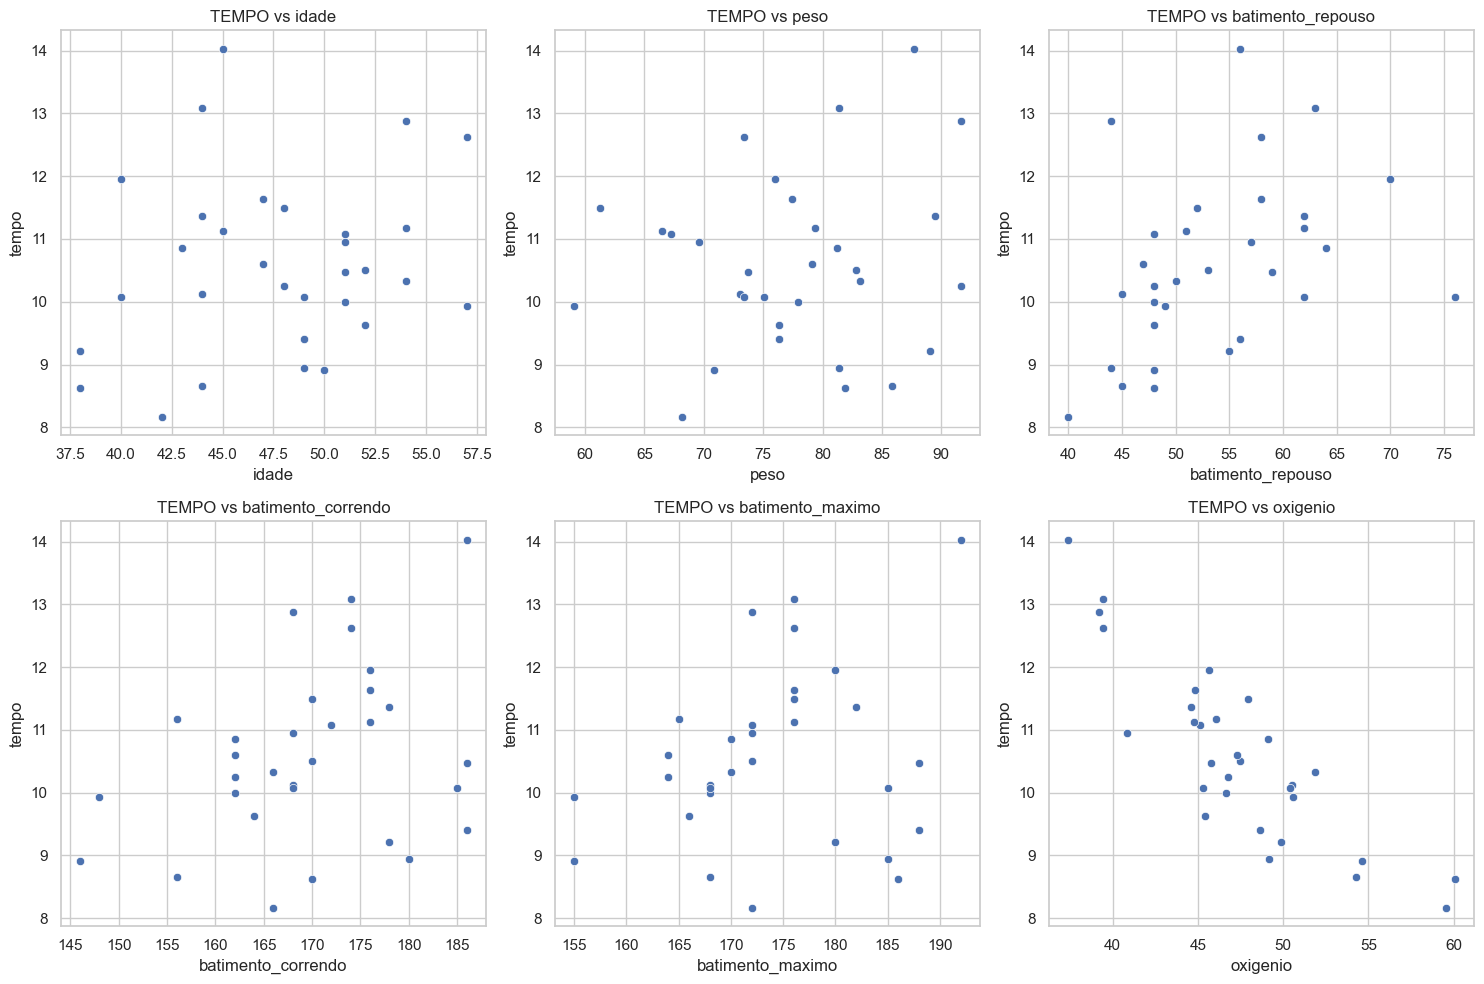

In [33]:
# a) Qual fator influencia no tempo e qual não influencia?
# Criar gráficos de dispersão para todas as variáveis numéricas contra 'Tempo'
variaveis = ['idade', 'peso','batimento_repouso','batimento_correndo', 'batimento_maximo', 'oxigenio']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(variaveis):
    sns.scatterplot(data=df3, x=var, y="tempo", ax=axes[i])
    axes[i].set_title(f"TEMPO vs {var}")

plt.tight_layout()
plt.show()

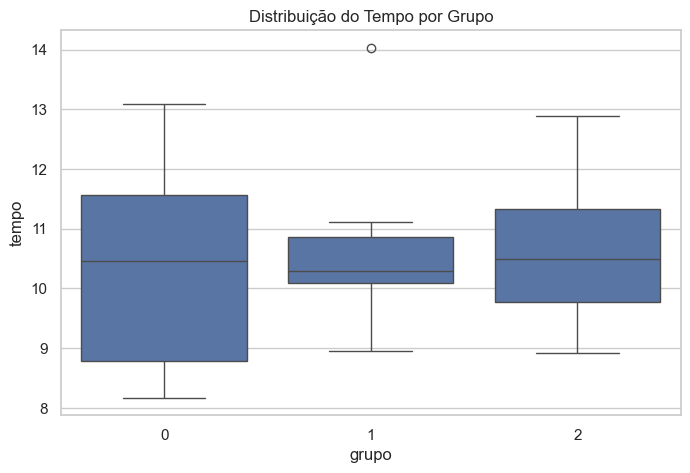

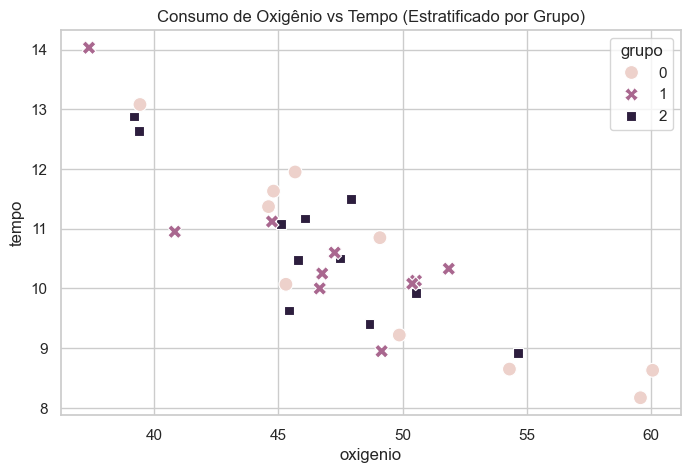

In [36]:
# b) O grupo influencia neste comportamento?
plt.figure(figsize=(8, 5))
sns.boxplot(data=df3, x="grupo", y="tempo")
plt.title("Distribuição do Tempo por Grupo")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df3, x="oxigenio", y="tempo", hue="grupo", style="grupo", s=100)
plt.title("Consumo de Oxigênio vs Tempo (Estratificado por Grupo)")
plt.show()

In [37]:
# c) Qual aparentemente tem a melhor correlação com o tempo?
matriz_correlacao = df3[variaveis + ["tempo"]].corr()
print("Correlação das variáveis com o Tempo:")
print(matriz_correlacao["tempo"].sort_values(ascending=False))

Correlação das variáveis com o Tempo:
tempo                 1.000000
batimento_repouso     0.400536
batimento_correndo    0.313648
batimento_maximo      0.226103
idade                 0.188745
peso                  0.143508
oxigenio             -0.862152
Name: tempo, dtype: float64
